In [ ]:
!pip install gTTS

In [ ]:


from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (3).zip


In [ ]:
import zipfile, os

for f in uploaded.keys():
    with zipfile.ZipFile(f, 'r') as z:
        z.extractall("data")

print("Folders inside data:", os.listdir("data"))

Folders inside data: ['test', 'train']


In [ ]:
print(os.listdir("data"))

['test', 'train']


In [ ]:
path = "data/train"

In [ ]:
import os, cv2, numpy as np
from sklearn.neighbors import KNeighborsClassifier

path = "data/train"

data = []
labels = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".jpg") or file.endswith(".png"):

            img_path = os.path.join(root, file)

            # label = folder name
            label = os.path.basename(root)

            img = cv2.imread(img_path, 0)
            if img is None:
                continue

            img = cv2.resize(img, (50,50))

            data.append(img.flatten())
            labels.append(label)

print("Loaded:", len(data))

if len(data) == 0:
    print("STILL NO DATA — show folder structure")
else:
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(data, labels)
    print("Model trained")

Loaded: 18000
Model trained


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import cv2
from gtts import gTTS
from IPython.display import Audio

def take_photo():
    js = Javascript('''
    async function takePhoto() {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise(r => setTimeout(r, 2000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      video.remove();

      return canvas.toDataURL('image/jpeg');
    }
    takePhoto();
    ''')

    display(js)
    data = eval_js('takePhoto()')
    binary = base64.b64decode(data.split(',')[1])

    with open('photo.jpg', 'wb') as f:
        f.write(binary)


take_photo()

img = cv2.imread("photo.jpg", 0)
img = cv2.resize(img, (50,50))

pred = model.predict([img.flatten()])[0]

print("Gesture:", pred)

tts = gTTS(pred)
tts.save("out.mp3")

Audio("out.mp3")

<IPython.core.display.Javascript object>

Gesture: 8


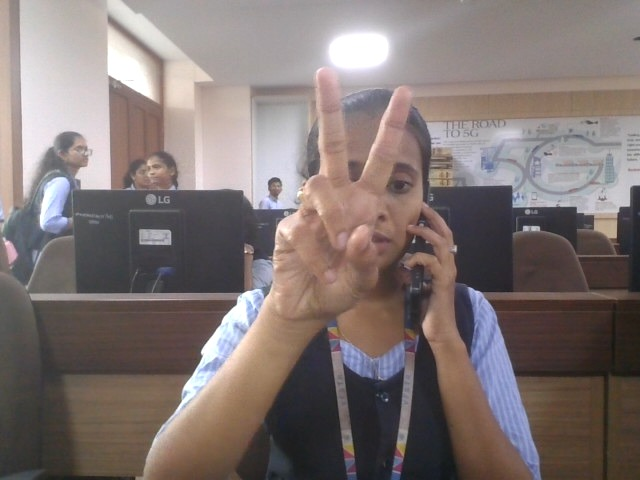

Gesture: Bad


In [ ]:
import cv2
from gtts import gTTS
from IPython.display import Audio, display
from PIL import Image
display(Image.open("photo.jpg"))

img = cv2.imread("photo.jpg", 0)
img = cv2.resize(img, (50,50))

pred = model.predict([img.flatten()])[0]

label_map = {
    "0": "hi",
    "1": "Yes",
    "2": "good morning",
    "3": "Thank You",
    "4": "Stop",
    "5": "OK",
    "6": "Peace",
    "7": "Good",
    "8": "Bad",
    "9": "Come",
    "10": "Go",
    "11": "Left",
    "12": "Right",
    "13": "Up",
    "14": "Down",
    "15": "Fine"
}

gesture_text = label_map.get(str(pred), "Gesture")

print("Gesture:", gesture_text)
tts = gTTS(text=gesture_text, lang='en')
tts.save("out.mp3")

Audio("out.mp3")